# Trading fees vs an EMA crossover on WBTC

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots
from algo_trading.backtest.config import PortfolioConfig

plots.apply_theme()

TOKEN = "wbtc"
FAST, SLOW = 5, 20                   # EMA spans, in days
FEES_PCT = [0, 0.1, 1, 5, 10]         # fee per fill (buy AND sell), in percent
INITIAL = 10_000
CFG = PortfolioConfig(check_bars=1)   # inspect the signal every bar

## Data

In [9]:
panel = data.daily_panel([TOKEN])
close = panel.close
price = close[TOKEN]
print(panel.describe())

854 1d bars x 1 tokens  2024-05-26 00:00:00+00:00 -> 2026-09-26 00:00:00+00:00


## Signal

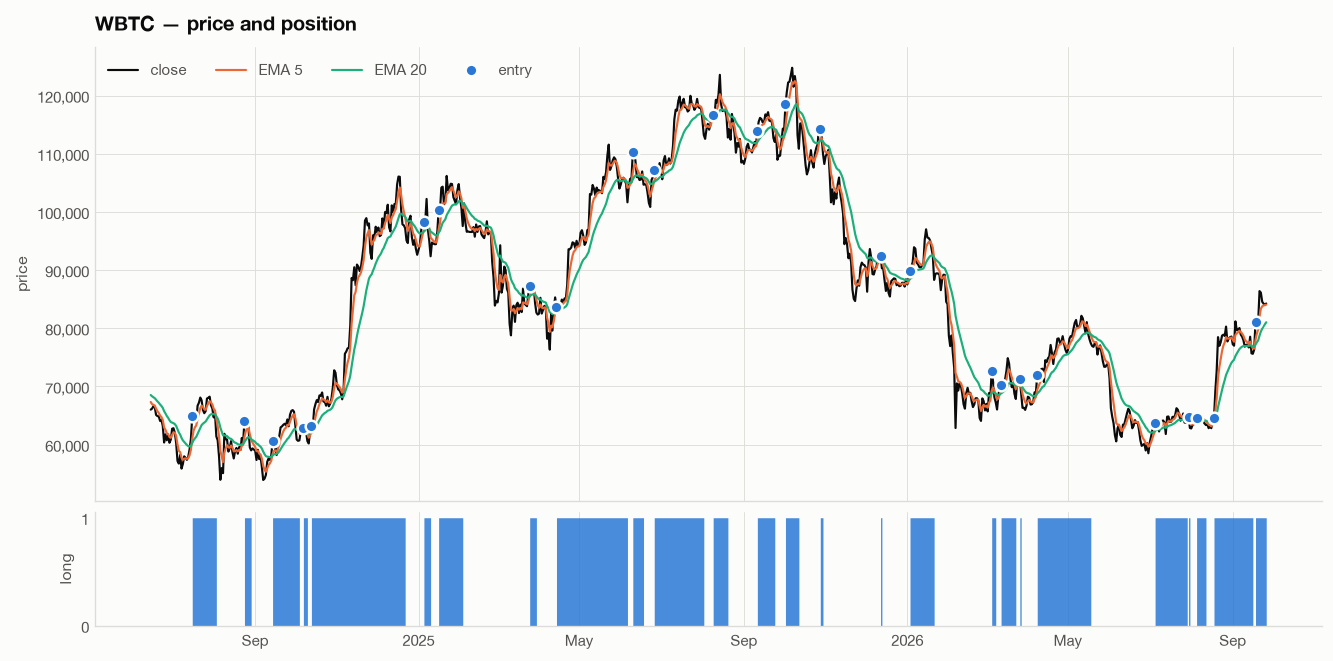

In [10]:
def ema_signal(price: pd.Series, fast: int, slow: int):
    """Long while the fast EMA is above the slow EMA, flat otherwise."""
    fast_ema = price.ewm(span=fast, adjust=False).mean()
    slow_ema = price.ewm(span=slow, adjust=False).mean()
    signal = (fast_ema > slow_ema).astype(float)
    signal.iloc[:slow] = 0.0
    return signal.to_frame(price.name), fast_ema, slow_ema


signal, ema_fast, ema_slow = ema_signal(price, FAST, SLOW)
plots.price_signal(price, signal[TOKEN], TOKEN, start=SLOW,
                   bands={f"EMA {FAST}": ema_fast, f"EMA {SLOW}": ema_slow})
plt.show()

## Backtest across fee levels

In [11]:
runs, rows = {}, []
for pct in FEES_PCT:
    label = f"{pct:g}% fee"
    res = bt.simulate(close, signal, CFG, fee_bps=pct * 100, initial=INITIAL, warmup=SLOW)
    row = bt.stats_from_result(res, label, SLOW, panel.bars_per_year,
                               exposure=float(signal[TOKEN].iloc[SLOW:].mean()))
    row["final_$"] = res["equity"].iloc[-1]
    runs[label], rows = res, rows + [row]

bh = price / price.iloc[SLOW] * INITIAL
bh_row = bt.perf(bh, "buy & hold", start=SLOW, initial=INITIAL, gross=1.0, exposure=1.0,
                 bars_per_year=panel.bars_per_year)
bh_row["final_$"] = bh.iloc[-1]

table = pd.DataFrame(rows + [bh_row]).set_index("label")
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "vol", "max_dd", "n_fills", "fees_pct", "exposure"]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}"})

,final_$,total_ret,sharpe,vol,max_dd,n_fills,fees_pct,exposure
label,,,,,,,,
0% fee,"$14,295",+43.0%,0.68,29%,-27.2%,51,0.00%,51%
0.1% fee,"$13,584",+35.8%,0.61,29%,-28.8%,51,6.15%,51%
1% fee,"$8,562",-14.4%,-0.09,29%,-42.8%,51,49.13%,51%
5% fee,"$1,045",-89.6%,-2.55,36%,-89.9%,51,107.19%,51%
10% fee,$66,-99.3%,-3.83,53%,-99.4%,51,106.35%,51%
buy & hold,"$12,764",+27.6%,0.46,46%,-53.1%,0,0.00%,100%


## Equity

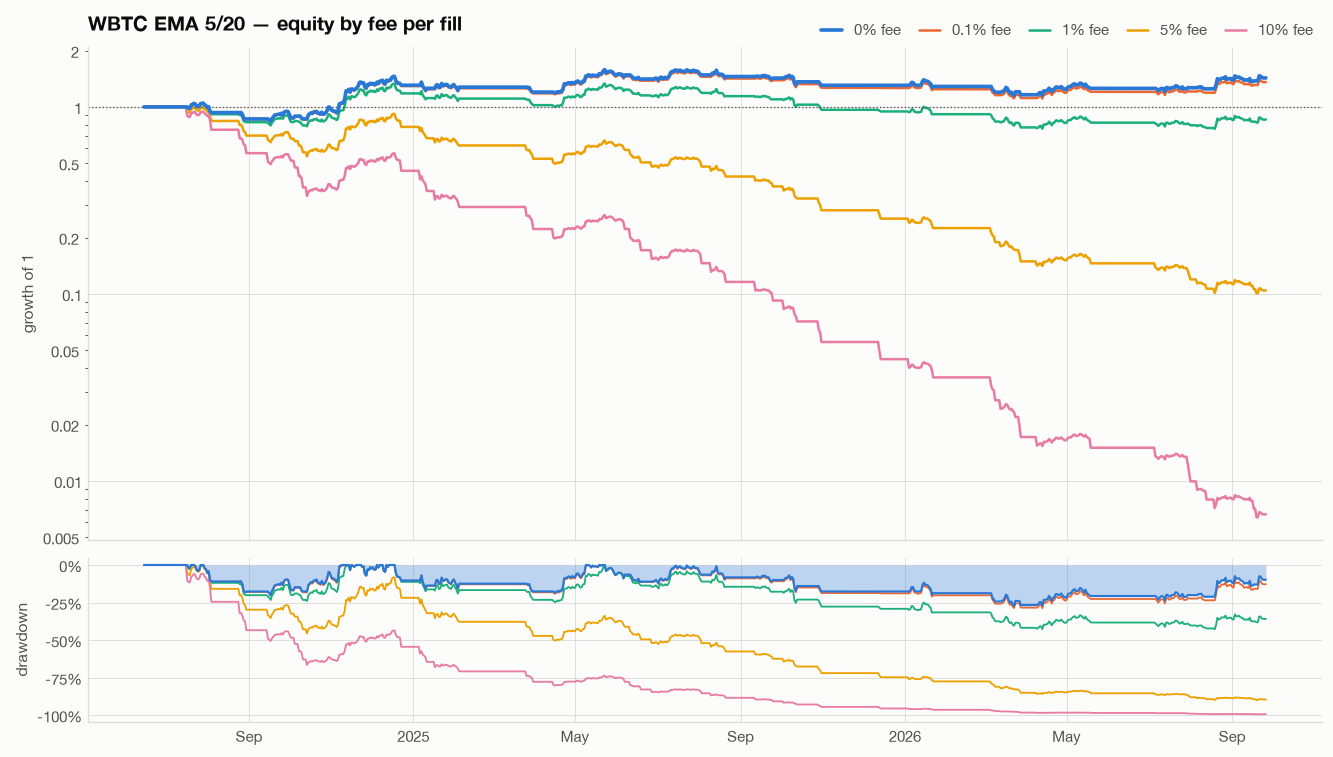

In [12]:
plots.equity_drawdown({k: r["equity"].iloc[SLOW:] for k, r in runs.items()},
                      f"{TOKEN.upper()} EMA {FAST}/{SLOW} — equity by fee per fill", log=True)
plt.show()

## Return and Sharpe vs fee

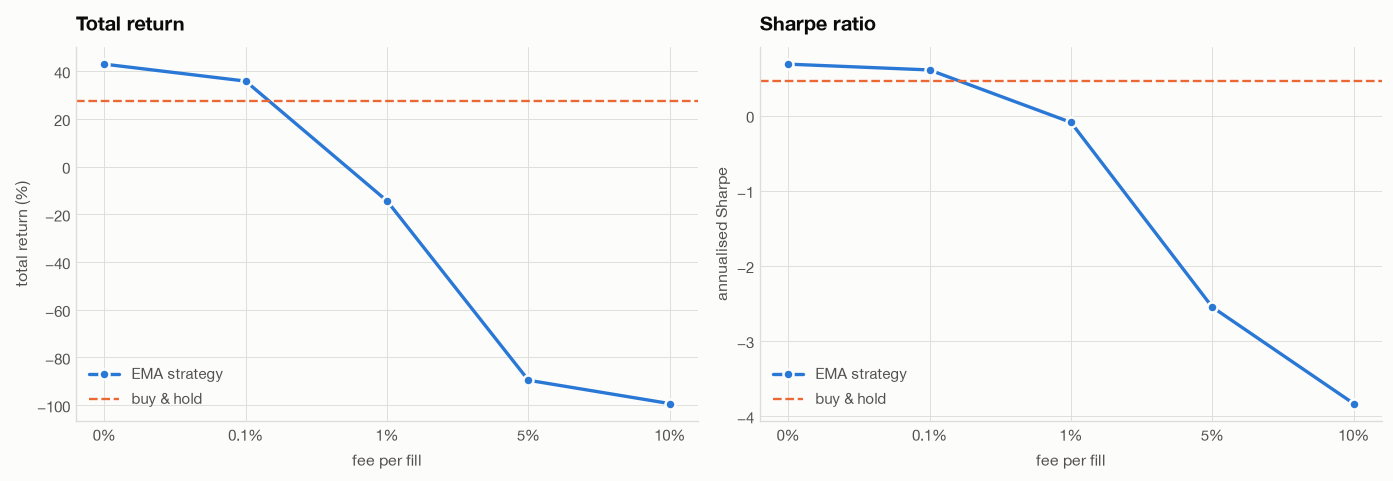

In [13]:
x, ticks = list(range(len(FEES_PCT))), [f"{p:g}%" for p in FEES_PCT]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), layout="constrained")
plots.sweep(x, {"EMA strategy": [r["total_ret"] * 100 for r in rows]},
            "Total return", "fee per fill", "total return (%)",
            hlines={"buy & hold": bh_row["total_ret"] * 100}, ax=axes[0])
plots.sweep(x, {"EMA strategy": [r["sharpe"] for r in rows]},
            "Sharpe ratio", "fee per fill", "annualised Sharpe",
            hlines={"buy & hold": bh_row["sharpe"]}, ax=axes[1])
for ax in axes:
    ax.set_xticks(x, ticks)
plt.show()

## Fee drag by EMA speed

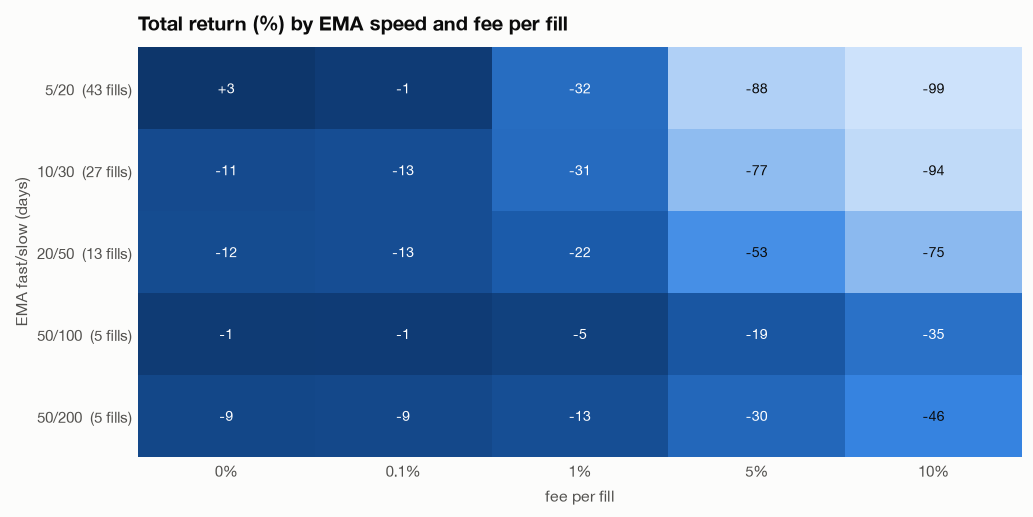

In [14]:
PAIRS = [(5, 20), (10, 30), (20, 50), (50, 100), (50, 200)]
GRID_WARMUP = max(slow for _, slow in PAIRS)   # common scoring window for every pair

grid, fills = {}, {}
for fast, slow in PAIRS:
    sig, _, _ = ema_signal(price, fast, slow)
    key = f"{fast}/{slow}"
    grid[key] = {}
    for pct in FEES_PCT:
        res = bt.simulate(close, sig, CFG, fee_bps=pct * 100, initial=INITIAL, warmup=GRID_WARMUP)
        eq = res["equity"].iloc[GRID_WARMUP:]
        grid[key][f"{pct:g}%"] = (eq.iloc[-1] / eq.iloc[0] - 1) * 100
    fills[key] = len(res["fills"])

surface = pd.DataFrame(grid).T
surface.index = [f"{k}  ({fills[k]} fills)" for k in surface.index]
plots.heatmap(surface, "Total return (%) by EMA speed and fee per fill", fmt="{:+.0f}",
              xlabel="fee per fill", ylabel="EMA fast/slow (days)", figsize=(8.5, 4.2))
plt.show()